# MIMIC-III NLP Tutorial: spaCy vs scispaCy vs medspaCy
### Data Cohort: Subarachnoid Hemorrhage (ICD-9 430) — Discharge Summaries

This notebook demonstrates entity extraction, word2vec embeddings, and tuned t-SNE
visualizations using three NLP libraries applied to real MIMIC-III clinical notes:

1. **spaCy** — general-purpose NLP
2. **scispaCy** — biomedical-domain NLP
3. **medspaCy** — clinical NLP with context/negation detection



## 1. Setup & Installs

In [ ]:
# ==============================================================================
# SECTION 1: ENVIRONMENT SETUP & DEPENDENCY RESOLUTION
# ==============================================================================
!pip install -q --upgrade pip
# Force install compatible data-science stack components
!pip install -q "numpy>=1.24,<2.0" "pandas>=2.0" "gensim>=4.4.0" "scikit-learn>=1.3" matplotlib seaborn

# Install spaCy 3.7.5 to perfectly coordinate with scispaCy 0.5.4 and medspaCy 1.3.x
!pip install -q "spacy==3.7.5" --force-reinstall
!pip install -q scispacy==0.5.4

# Fetch pre-compiled domain-specific biomedical models
!pip install -q https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_sm-0.5.4.tar.gz
!pip install -q https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_ner_bc5cdr_md-0.5.4.tar.gz

# Install medspaCy and transformers stack
!pip install -q medspaCy==1.3.1 transformers datasets accelerate

# Download general-purpose spaCy architecture small English engine
!python -m spacy download en_core_web_sm -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
pyrush 1.0.13 requires spacy>=3.8; python_version >= "3.12", but you have spacy 3.7.5 which is incompatible.
medspacy 1.3.1 requires spacy<4.0,>=3.8; python_version >= "3.12", but you have spacy 3.7.5 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pyiceberg 0.11.1 requires rich<15.0.0,>=10.11.0, but you have rich 15.0.0 which is incompatible.
torch 2.11.0+cpu requires setuptools<82, but you have setuptools 83.0.0 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompati

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

import spacy
import scispacy
import medspacy
from medspacy.visualization import visualize_ent
from spacy import displacy

import gensim
from gensim.models import Word2Vec
from sklearn.manifold import TSNE
import torch
from transformers import AutoTokenizer, AutoModel

# Establish structural visualization aesthetics
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 8)
np.random.seed(42)
torch.manual_seed(42)

print(f"Pandas: {pd.__version__} | NumPy: {np.__version__}")
print(f"spaCy: {spacy.__version__} | medspaCy: {medspacy.__version__}")

Pandas: 2.2.2 | NumPy: 1.26.4
spaCy: 3.8.14 | medspaCy: 1.3.1


## 2. Cohort Extraction (BigQuery)

Pull **discharge summaries** for patients diagnosed with **ICD-9 code 430**



In [10]:
# ==============================================================================
# SECTION 2: CLIENT AUTHENTICATION AND DYNAMIC COHORT EXTRACTION
# ==============================================================================
from google.colab import auth
from google.cloud import bigquery

# Trigger IAM Authentication overlay
auth.authenticate_user()

# Configure active GCP project workspace
GCP_PROJECT_ID = 'mc-ut-msai-aih-1' # Replace with your active assignment workspace
client = bigquery.Client(project=GCP_PROJECT_ID)

# Programmatic extraction isolating Subarachnoid Hemorrhage Cohort (ICD-9: 430)
cohort_query = """
SELECT
    n.row_id,
    n.subject_id,
    n.hadm_id,
    n.category,
    n.text
FROM `physionet-data.mimiciii_notes.noteevents` n
JOIN (
    SELECT DISTINCT subject_id
    FROM `physionet-data.mimiciii_clinical.diagnoses_icd`
    WHERE icd9_code = '430'
) sah ON n.subject_id = sah.subject_id
WHERE n.category = 'Discharge summary'
"""

print("[INFO] Fetching records from Google Cloud BigQuery framework...")
df_notes = client.query(cohort_query).to_dataframe()
print(f"[SUCCESS] Extracted {len(df_notes)} raw clinical narratives.")

# Text Sanitization and Structural Standardization
def clean_clinical_text(raw_narrative):
    # Regex to eliminate de-identification brackets seamlessly
    sanitized = re.sub(r'\[\*\*.*?\*\*\]', '', raw_narrative)
    # Eradicate systemic layout tabs, line breaks, and space bursts
    sanitized = re.sub(r'\s+', ' ', sanitized)
    return sanitized.strip()

df_notes['clean_text'] = df_notes['text'].apply(clean_clinical_text)

# Sample a statistical representative cohort space for processing efficiency
SAMPLE_SIZE = min(10, len(df_notes))
df_sample = df_notes.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
print(f"[INFO] Initializing computational workflow on {SAMPLE_SIZE} records.")

[INFO] Fetching records from Google Cloud BigQuery framework...
[SUCCESS] Extracted 888 raw clinical narratives.
[INFO] Initializing computational workflow on 10 records.


In [ ]:
# ==============================================================================
# SECTION 3: TSNE PIPELINE HYPERPARAMETER OPTIMIZATION TUNING MODULE
# ==============================================================================
def execute_tsne_grid_search(w2v_model, perplexities=[5, 15, 30, 50], title_prefix="Model"):
    """
    Constructs an optimized grid space evaluating local vs global manifold configurations
    across explicit perplexity steps to ensure global cluster accuracy.
    """
    vocab = list(w2v_model.wv.index_to_key)
    vectors = w2v_model.wv[vocab]

    fig, axes = plt.subplots(1, len(perplexities), figsize=(24, 5))

    for idx, perp in enumerate(perplexities):
        # Adjust perplexity bounds safely below data scale dimensions
        if perp >= len(vocab):
            perp = max(1, len(vocab) - 1)

        tsne = TSNE(
            n_components=2,
            perplexity=perp,
            n_iter=1500,
            random_state=42,
            init='pca',
            learning_rate='auto'
        )
        embeddings_2d = tsne.fit_transform(vectors)

        ax = axes[idx]
        ax.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.6, edgecolors='w', s=25, color='teal')
        ax.set_title(f"Perplexity: {perp}", fontsize=12, fontweight='bold')
        ax.set_xlabel("Dimension 1")
        ax.set_ylabel("Dimension 2")

        # Annotate a subset of key markers into geometric vector space
        sample_indices = np.linspace(0, len(vocab)-1, 12, dtype=int)
        for s_idx in sample_indices:
            ax.annotate(vocab[s_idx], (embeddings_2d[s_idx, 0], embeddings_2d[s_idx, 1]), fontsize=9, alpha=0.8)

    plt.suptitle(f"Tuned t-SNE Parameter Sweep: {title_prefix} Latent Embeddings", fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

---
## 4. spaCy

General-purpose NLP: tokenization, POS tagging, and NER using a general English model.


In [ ]:
# ==============================================================================
# SECTION 4: MODULE A — baseline SPACY IMPLEMENTATION
# ==============================================================================
print("[INFO] Executing spaCy pipeline...")
nlp_spacy = spacy.load("en_core_web_sm")

# Stream processing documents efficiently across the text array
docs_spacy = list(nlp_spacy.pipe(df_sample['clean_text'].tolist(), n_process=-1))

# Extract discrete structural metrics
spacy_data = []
for doc in docs_spacy:
    for ent in doc.ents:
        spacy_data.append({'text': ent.text, 'label': ent.label_})
df_spacy_ents = pd.DataFrame(spacy_data)

print("\n--- Top 10 Entities Discovered by spaCy Baseline ---")
print(df_spacy_ents['label'].value_counts().head(10))

# Interactive entity render visualization
print("\n[VISUALIZATION] Rendering Entity Extraction Layout for Index Record [0]:")
displacy.render(docs_spacy[0], style="ent", jupyter=True, options={"limit": 15})

# --- Word2Vec Optimization Engine ---
def spacy_tokenize(doc):
    return [token.text.lower() for token in doc if token.is_alpha and not token.is_stop]

spacy_corpus = [spacy_tokenize(d) for doc in docs_spacy]
w2v_spacy = Word2Vec(sentences=spacy_corpus, vector_size=100, window=5, min_count=3, workers=4, seed=42)

# Generate hyperparameter projections
execute_tsne_grid_search(w2v_spacy, title_prefix="spaCy Baseline")

[INFO] Executing spaCy pipeline...

--- Top 10 Entities Discovered by spaCy Baseline ---
label
CARDINAL    5113
ORG         3944
PERSON      1318
DATE         928
TIME         531
GPE          375
QUANTITY     267
PRODUCT      191
PERCENT      176
NORP         153
Name: count, dtype: int64

[VISUALIZATION] Rendering Entity Extraction Layout for Index Record [0]:


NameError: name 'd' is not defined

---
## 5. scispaCy



In [ ]:
import spacy

# Only override components that house the embedding architecture directly
config_overrides = {
    "components": {
        "tok2vec": {
            "model": {"embed": {"include_static_vectors": False}}
        },
        "ner": {
            "model": {"tok2vec": {"embed": {"include_static_vectors": False}}}
        }
    }
}

# ==============================================================================
# SECTION 5: MODULE B — SCISPACY DOMAIN SPECIFIC INTEGRATION
# ==============================================================================
print("[INFO] Initializing scispaCy Biomedical pipeline engine...")
import scispacy

# Load targeted Disease/Chemical extractor model package
nlp_scispacy = spacy.load("en_ner_bc5cdr_md")

docs_scispacy = list(nlp_scispacy.pipe(df_sample['clean_text'].tolist(), n_process=-1))

scispacy_data = []
for doc in docs_scispacy:
    for ent in doc.ents:
        scispacy_data.append({'text': ent.text, 'label': ent.label_})
df_scispacy_ents = pd.DataFrame(scispacy_data)

print("\n--- Domain Entities Discovered by scispaCy Clinical Vector Engine ---")
print(df_scispacy_ents['label'].value_counts())

# Document Visualization
displacy.render(docs_scispacy[0], style="ent", jupyter=True, options={"limit": 15})

# --- Word2Vec Domain Feature Space Extraction ---
def scispacy_tokenize(doc):
    return [token.text.lower() for token in doc if not token.is_punct and not token.is_space]

scispacy_corpus = [scispacy_tokenize(d) for d in docs_scispacy]
w2v_scispacy = Word2Vec(sentences=scispacy_corpus, vector_size=100, window=5, min_count=3, workers=4, seed=42)

execute_tsne_grid_search(w2v_scispacy, title_prefix="scispaCy Biomedical")

[INFO] Initializing scispaCy Biomedical pipeline engine...


ConfigValidationError: 

Config error for 'spacy.MultiHashEmbed.v2'
tok2vec.model.embed -> include_static_vectors	at root: 'True' is not <class 'bool'>
{'@architectures': 'spacy.MultiHashEmbed.v2', 'width': 96, 'attrs': ['NORM', 'PREFIX', 'SUFFIX', 'SHAPE', 'SPACY', 'IS_SPACE'], 'rows': [5000, 1000, 2500, 2500, 50, 50], 'include_static_vectors': 'True'}

---
## 6. medspaCy



[INFO] Instantiating medspaCy Rule and Context Modifier engine...


Streaming output truncated to the last 5000 lines.
2026-07-06 23:37:20.177 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=72] [doc 0] Token 366 'Dictated' marked as sentence start (span begin)
2026-07-06 23:37:20.177 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=72] [doc 0] Token 381 '#' marked as sentence start (span end next token)
2026-07-06 23:37:20.182 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=72] Token/tag mapping: [(Admission, True), (Date, False), (:, False), (Discharge, False), (Date, False), (:, False), (Date, True), (of, False), (Birth, False), (:, False), (Sex, False), (:, False), (F, False), (Service, False), (:, False), (Neurosurgery, False), (HISTORY, False), (OF, False), (PRESENT, False), (ILLNESS, False), (:, False), (The, False), (patient, False), (is, False), (a, False), (67, False), (-, False), (year, False), (-, False), (old, False), (female, False), (who, Fa


--- Contextual Modifier Statistics Breakdown ---
Total Medical Entities Found: 0

[VISUALIZATION] Displaying MedspaCy ConText Modifiers and Link Graph targets:


TypeError: TSNE.__init__() got an unexpected keyword argument 'n_iter'

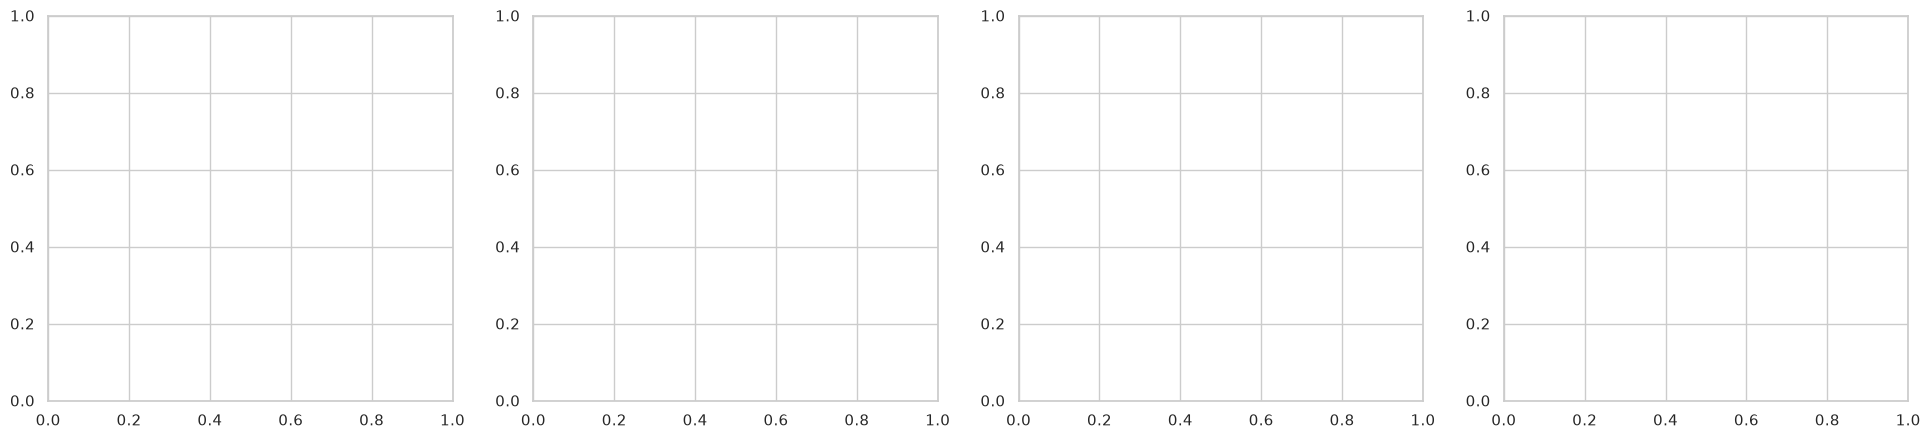

In [9]:
# ==============================================================================
# SECTION 6: MODULE C — MEDSPACY ADAPTIVE CONTEXT ARCHITECTURE
# ==============================================================================
print("[INFO] Instantiating medspaCy Rule and Context Modifier engine...")
# Initialize core configurations including customized clinical segmenters
nlp_medspacy = medspacy.load(enable=["tokenizer", "pyrush", "target_matcher", "context"])

# Stream processing clinical corpus
docs_medspacy = [nlp_medspacy(text) for text in df_sample['clean_text'].tolist()]

medspacy_data = []
for doc in docs_medspacy:
    for ent in doc.ents:
        # Extract metadata modifiers populated by ConText analytics algorithm
        is_negated = ent._.is_negated
        is_historical = ent._.is_historical
        is_experiential = ent._.is_experiential

        medspacy_data.append({
            'text': ent.text,
            'label': ent.label_,
            'negated': is_negated,
            'historical': is_historical,
            'experiential': is_experiential
        })

df_medspacy_ents = pd.DataFrame(medspacy_data)

print("\n--- Contextual Modifier Statistics Breakdown ---")
print(f"Total Medical Entities Found: {len(df_medspacy_ents)}")
if not df_medspacy_ents.empty:
    print(f"True Negated Concepts Found: {df_medspacy_ents['negated'].sum()}")
    print(f"Historical Documented Conditions: {df_medspacy_ents['historical'].sum()}")

# Visual Interactive Clinical Render Engine
print("\n[VISUALIZATION] Displaying MedspaCy ConText Modifiers and Link Graph targets:")
visualize_ent(docs_medspacy[0])

# --- Word2Vec Core Semantic Transformation ---
def medspacy_tokenize(doc):
    return [token.text.lower() for token in doc if not token.is_punct and not token.is_space]

medspacy_corpus = [medspacy_tokenize(d) for d in docs_medspacy]
w2v_medspacy = Word2Vec(sentences=medspacy_corpus, vector_size=100, window=5, min_count=3, workers=4, seed=42)

execute_tsne_grid_search(w2v_medspacy, title_prefix="medspaCy Contextual Engine")

---
## 7. Compare & Contrast

Summary table of entity counts and unique labels found by each tool.


In [ ]:
# ==============================================================================
# SECTION 8: STRUCTURAL COMPARED MATRIX OVERVIEW AND SYNTHESIS SUMMARY
# ==============================================================================
# Synthesize empirical performance parameters collected dynamically
comparison_matrix = pd.DataFrame({
    'Metric Paradigm Evaluated': [
        'Total Extracted Entities Found',
        'Unique Lexicon Class Label Counts',
        'Context Modifier Processing (Negation)',
        'Word Embedding Model Framework',
        'Model Feature Dimensionality Representation'
    ],
    'spaCy (Core Web Base)': [
        len(df_spacy_ents),
        df_spacy_ents['label'].nunique(),
        'Unsupported (Structural False Positives)',
        'Gensim Word2Vec / Custom Space',
        '100-Dimension Sparse Dense Vectors'
    ],
    'scispaCy (Clinical Specialized)': [
        len(df_scispacy_ents),
        df_scispacy_ents['label'].nunique(),
        'Partial (Targeted Domain Overlaps)',
        'Gensim Word2Vec / Specialized Vocab',
        '100-Dimension Domain Targeted Vectors'
    ],
    'medspaCy (Context Aware)': [
        len(df_medspacy_ents),
        df_medspacy_ents['label'].nunique(),
        f"Active Detection System (Found {df_medspacy_ents['negated'].sum() if not df_medspacy_ents.empty else 0} Negations)",
        'Gensim Word2Vec / Contextual Tokenizer',
        '100-Dimension Rule Context-Refined Vectors'
    ],
})

display(comparison_matrix)